<h2>Exercise 03: Bar charts</h2>

In [1]:
import pandas as pd 
import sqlite3

### 1. Preprocessing

In [55]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [81]:
df = pd.io.sql.read_sql(
    """
    SELECT
        * 
    FROM checker
    WHERE uid LIKE "user_%" 
    """,
    conn,
    parse_dates=["timestamp"]
    
)

df

,index,status,success,timestamp,numTrials,labname,uid
0,7,ready,0,2020-04-17 05:19:02.744528,1,project1,user_4
1,8,checking,0,2020-04-17 05:22:35.249331,2,project1,user_4
2,9,ready,1,2020-04-17 05:22:45.549397,2,project1,user_4
3,10,checking,1,2020-04-17 05:34:14.691200,3,project1,user_4
4,11,ready,1,2020-04-17 05:34:24.422370,3,project1,user_4
...,...,...,...,...,...,...,...
3202,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1
3203,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1
3204,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1
3205,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1


In [82]:
df["date"] = df["timestamp"].dt.date
df["weekday"] = df["timestamp"].dt.weekday
df["hour"] = df["timestamp"].dt.hour
df

,index,status,success,timestamp,numTrials,labname,uid,date,weekday,hour
0,7,ready,0,2020-04-17 05:19:02.744528,1,project1,user_4,2020-04-17,4,5
1,8,checking,0,2020-04-17 05:22:35.249331,2,project1,user_4,2020-04-17,4,5
2,9,ready,1,2020-04-17 05:22:45.549397,2,project1,user_4,2020-04-17,4,5
3,10,checking,1,2020-04-17 05:34:14.691200,3,project1,user_4,2020-04-17,4,5
4,11,ready,1,2020-04-17 05:34:24.422370,3,project1,user_4,2020-04-17,4,5
...,...,...,...,...,...,...,...,...,...,...
3202,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1,2020-05-21,3,20
3203,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1,2020-05-21,3,20
3204,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1,2020-05-21,3,20
3205,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1,2020-05-21,3,20


In [83]:
df["day_type"] = df["weekday"].apply(
    lambda x: "working" if x < 5 else "weekend"
)

df

,index,status,success,timestamp,numTrials,labname,uid,date,weekday,hour,day_type
0,7,ready,0,2020-04-17 05:19:02.744528,1,project1,user_4,2020-04-17,4,5,working
1,8,checking,0,2020-04-17 05:22:35.249331,2,project1,user_4,2020-04-17,4,5,working
2,9,ready,1,2020-04-17 05:22:45.549397,2,project1,user_4,2020-04-17,4,5,working
3,10,checking,1,2020-04-17 05:34:14.691200,3,project1,user_4,2020-04-17,4,5,working
4,11,ready,1,2020-04-17 05:34:24.422370,3,project1,user_4,2020-04-17,4,5,working
...,...,...,...,...,...,...,...,...,...,...,...
3202,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1,2020-05-21,3,20,working
3203,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1,2020-05-21,3,20,working
3204,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1,2020-05-21,3,20,working
3205,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1,2020-05-21,3,20,working


In [84]:
def get_mean_hours(df):
    grouped = df.groupby(['date', 'hour'])['uid'].count().reset_index()
    return grouped.groupby('hour')['uid'].mean()

In [86]:
df_weekend = get_mean_hours(df[df["day_type"] == "weekend"])
df_weekend

hour
0      2.000000
1      6.000000
3      1.000000
5      2.000000
7      4.000000
8      7.000000
9      3.666667
10     7.000000
11    23.600000
12     9.500000
13    18.000000
14    12.428571
15    14.250000
16    14.800000
17     7.142857
18     9.714286
19    13.125000
20    13.000000
21    10.285714
22     9.833333
23     6.400000
Name: uid, dtype: float64

In [87]:
df_working = get_mean_hours(df[df["day_type"]=="working"])
df_working

hour
0      3.000000
3      2.000000
5      7.500000
6      1.500000
7      5.166667
8      3.700000
9      6.000000
10    13.200000
11     6.769231
12     7.181818
13     8.111111
14    10.166667
15    12.818182
16    18.888889
17    16.000000
18    15.181818
19    17.833333
20    14.076923
21    24.333333
22     3.750000
23     5.000000
Name: uid, dtype: float64

In [90]:
df_working = df_working.reindex(range(24), fill_value=0)
df_weekend = df_weekend.reindex(range(24), fill_value=0)


result = pd.DataFrame(
    {
        "weekend": df_weekend,
        "working": df_working
    }
)

result

,weekend,working
hour,,
0,2.000000,3.000000
1,6.000000,0.000000
2,0.000000,0.000000
3,1.000000,2.000000
4,0.000000,0.000000
5,2.000000,7.500000
6,0.000000,1.500000
7,4.000000,5.166667
8,7.000000,3.700000


array([[<Axes: title={'center': 'weekend'}, xlabel='hour'>],
       [<Axes: title={'center': 'working'}, xlabel='hour'>]], dtype=object)

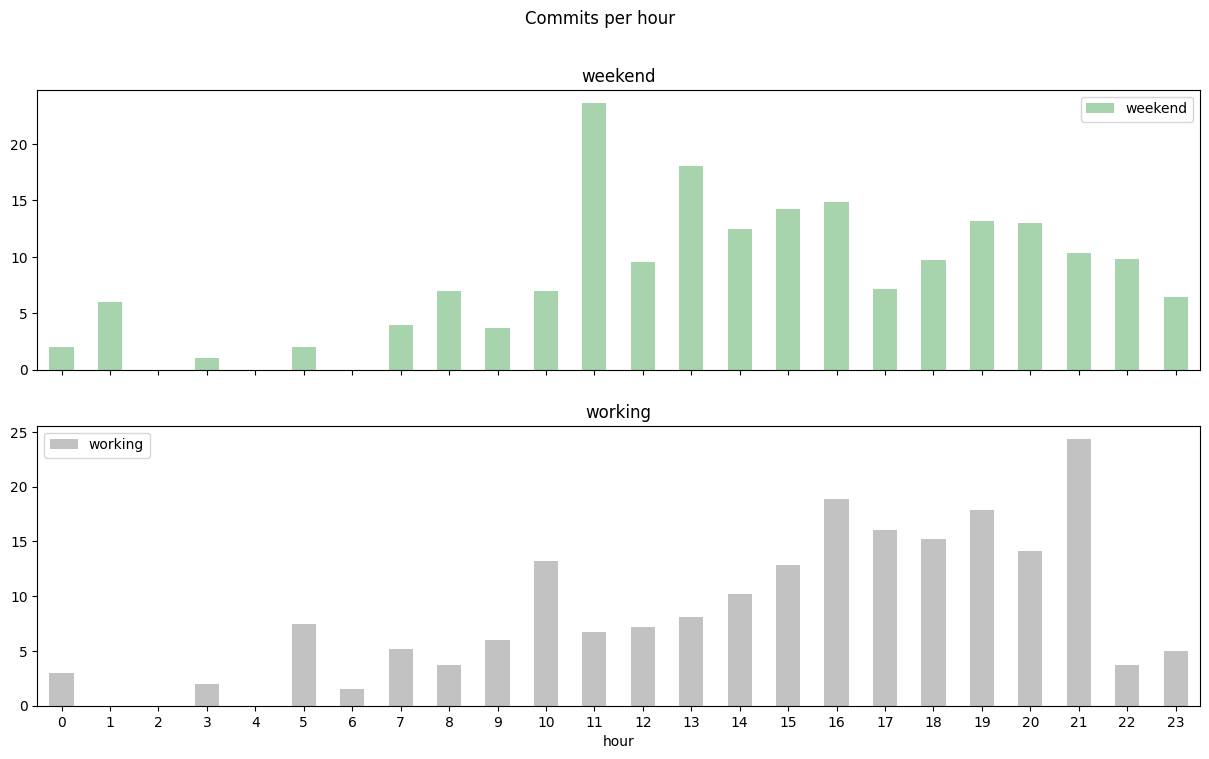

In [91]:
result.plot(
    kind="bar",
    subplots=True,
    layout=(2, 1),
    figsize=(15, 8),
    color=['#a8d4ad', '#c2c2c2'],
    rot=0,
    title='Commits per hour'

)

<h2>В выходные дни - 11 часов</h2>
<h2>В будние дни - 21 час</h2>